# Feature Engineering

This notebook transforms the EDA checkpoint into model-ready datasets for
four regression models: Linear Regression, Random Forest, SVR, and XGBoost.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression, VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

Matplotlib settings for LaTeX-compatible PDF exports.

In [38]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "text.usetex": True
})

In [39]:
ROOT = Path.cwd().parent
DATA = ROOT / "data"
INTERIM = DATA / "interim"
CHECKPOINT = INTERIM / "checkpoints"
PROCESSED = DATA / "processed"
REPORT_FE = ROOT / "reports" / "feature_engineering"

PROCESSED.mkdir(parents=True, exist_ok=True)
REPORT_FE.mkdir(parents=True, exist_ok=True)

## 1. Data Loading and Leakage Removal

In [40]:
df = pd.read_csv(CHECKPOINT / "ev_phase1_cleaned.csv")
print(f"Loaded: {df.shape}")
df.head()

Loaded: (3963, 19)


,id,brand,base_model,model_mode,year,condition,mileage_km,has_aftermarket_mods,body_type,seats,doors,drivetrain,origin,exterior_color,city,seller_name,post_date,website,price_vnd
0,0,VinFast,VF8,VF8 Plus AWD,2023.0,Used,50000.0,False,SUV,5.0,5.0,AWD,Lắp ráp trong nước,Đen,Hà Nội,GF Hoàng Quốc Việt,2026-02-28,bonbanh.com,659000000.0
1,1,VinFast,VF8,VF8 Eco,2026.0,New,0.0,False,SUV,5.0,5.0,FWD,Lắp ráp trong nước,Trắng,Hà Nội,Vinfast Times City,2026-02-28,bonbanh.com,790000000.0
2,2,VinFast,VF8,VF8 Plus AWD,2023.0,Used,99000.0,False,SUV,5.0,5.0,AWD,Lắp ráp trong nước,Xanh,Hà Nội,GF Hoàng Quốc Việt,2026-02-28,bonbanh.com,599000000.0
3,3,VinFast,VF8,VF8 Eco AWD,2023.0,Used,55000.0,False,SUV,5.0,5.0,AWD,Lắp ráp trong nước,Xám,Hà Nội,Đức Lộc,2026-02-28,bonbanh.com,580000000.0
4,4,VinFast,VF5,VF5 Plus,2024.0,Used,45000.0,False,SUV,5.0,5.0,FWD,Lắp ráp trong nước,Xám,Hà Nội,Tấn Nhất Tín,2026-02-28,bonbanh.com,399000000.0


In [41]:
# Drop leakage / identifier columns
LEAKAGE_COLS = ["id", "seller_name", "post_date", "website"]
df = df.drop(columns=LEAKAGE_COLS)
print(f"After leakage removal: {df.shape}")  # expect (3963, 15)

After leakage removal: (3963, 15)


In [42]:
# Snapshot of missing values before imputation
print("Missing values before imputation:")
missing = df.isnull().sum()
print(missing[missing > 0].to_string())

Missing values before imputation:
brand              27
year               67
mileage_km        281
exterior_color    189


## 2. Missing Value Imputation

**Brand** (27 NaN): All missing-brand rows are VinFast models (VF3, VF5, VF6, VF7, VF8,
Limo Green, Herio Green, EC Van). We impute using a base\_model $\to$ brand lookup.

In [43]:
# Brand imputation from base_model lookup
brand_lookup = (
    df.dropna(subset=["brand"])
    .groupby("base_model")["brand"]
    .agg(lambda x: x.mode().iloc[0])
)
mask = df["brand"].isna()
df.loc[mask, "brand"] = df.loc[mask, "base_model"].map(brand_lookup)
print(f"Brand NaN after imputation: {df['brand'].isna().sum()}")

Brand NaN after imputation: 0


**Year** (67 NaN): Impute with the median year of the same `base\_model`, falling back to the global median.

In [44]:
# Year imputation by base_model median
year_medians = df.groupby("base_model")["year"].transform("median")
df["year"] = df["year"].fillna(year_medians)
df["year"] = df["year"].fillna(df["year"].median())
print(f"Year NaN after imputation: {df['year'].isna().sum()}")

Year NaN after imputation: 0


**Mileage** (281 NaN): New cars with missing mileage get 0 km. Used cars get the median mileage of the Used group.

In [45]:
# Mileage imputation: New -> 0, Used -> Used median
used_median_mileage = df.loc[df["condition"] == "Used", "mileage_km"].median()
df.loc[(df["mileage_km"].isna()) & (df["condition"] == "New"), "mileage_km"] = 0
df.loc[(df["mileage_km"].isna()) & (df["condition"] == "Used"), "mileage_km"] = used_median_mileage
print(f"Mileage NaN after imputation: {df['mileage_km'].isna().sum()}")
print(f"Used median mileage used: {used_median_mileage:,.0f} km")

Mileage NaN after imputation: 0
Used median mileage used: 20,000 km


**Doors** (24 zeros): 24 records have `doors=0` (mostly VF MPV 7). Impute with the mode of the same `base\_model`.

In [46]:
# Doors: replace 0 with mode by base_model
doors_zero_mask = df["doors"] == 0
doors_mode = df[~doors_zero_mask].groupby("base_model")["doors"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 5)
df.loc[doors_zero_mask, "doors"] = df.loc[doors_zero_mask, "base_model"].map(doors_mode).fillna(5)
print(f"Doors=0 after fix: {(df['doors'] == 0).sum()}")

Doors=0 after fix: 0


**Exterior color** (189 NaN): Map Vietnamese colour names to English, fill NaN with ``Unknown''.

In [47]:
# Exterior color: Vietnamese -> English mapping
COLOR_MAP = {
    "Trắng": "White", "Đỏ": "Red", "Đen": "Black", "Xám": "Gray",
    "Xanh": "Blue", "Xanh lá": "Green", "Vàng": "Yellow",
    "Xanh dương": "Blue", "Hồng": "Pink", "Bạc": "Silver",
    "Màu khác": "Other", "Khác": "Other", "Cam": "Orange",
    "Ghi": "Gray", "Tím": "Purple", "Nhiều màu": "Multi",
    "Nâu": "Brown", "Nhiều Màu": "Multi", "-": "Unknown",
    "Đồng": "Bronze", "Đen+Trắng": "Other", "Vàng/Trắng": "Other",
    "Hồng Tím": "Other", "Hồng Phấn": "Other", "Xanh Dương": "Blue",
    "Trắng nóc Bạc": "Other", "Xanh Rêu": "Green",
}
df["exterior_color"] = df["exterior_color"].map(COLOR_MAP).fillna("Unknown")
print(f"Exterior color NaN after mapping: {df['exterior_color'].isna().sum()}")
print(df["exterior_color"].value_counts().to_string())

Exterior color NaN after mapping: 0
exterior_color
White      1083
Red         567
Gray        484
Black       470
Blue        379
Other       197
Unknown     191
Green       164
Yellow      155
Pink        106
Silver      106
Orange       40
Multi         9
Purple        7
Brown         4
Bronze        1


**Origin**: Map Vietnamese labels to Domestic / Imported / Unknown.

In [48]:
# Origin: Vietnamese -> English mapping
ORIGIN_MAP = {
    "Việt Nam": "Domestic",
    "Lắp ráp trong nước": "Domestic",
    "Đang cập nhật": "Unknown",
    "Nhập khẩu": "Imported",
    "Nước khác": "Imported",
    "Trung Quốc": "Imported",
    "Đức": "Imported",
    "Nhật Bản": "Imported",
}
df["origin"] = df["origin"].map(ORIGIN_MAP)
print(f"Origin NaN after mapping: {df['origin'].isna().sum()}")
print(df["origin"].value_counts().to_string())

Origin NaN after mapping: 0
origin
Domestic    3434
Unknown      314
Imported     215


**City**: Map top Vietnamese city names to English, group rare cities ($<20$ records) into ``Other''.

In [49]:
# City: Vietnamese -> English + rare grouping
CITY_MAP = {
    "Hà Nội": "Hanoi",
    "Hồ Chí Minh": "HCMC",
    "Đà Nẵng": "Da Nang",
    "Tỉnh/Thành Khác": "Other",
    "Cần Thơ": "Can Tho",
    "Hải Phòng": "Hai Phong",
    "Đồng Nai": "Dong Nai",
    "Vĩnh Phúc": "Vinh Phuc",
    "Phú Thọ": "Phu Tho",
    "Đắk Lắk": "Dak Lak",
}
df["city"] = df["city"].map(CITY_MAP).fillna("Other")
# Group any city with < 20 records into Other
city_counts = df["city"].value_counts()
rare_cities = city_counts[city_counts < 20].index
df.loc[df["city"].isin(rare_cities), "city"] = "Other"
print(f"City unique after grouping: {df['city'].nunique()}")
print(df["city"].value_counts().to_string())

City unique after grouping: 10
city
Hanoi        1993
HCMC         1281
Other         316
Da Nang       139
Can Tho        70
Hai Phong      44
Dong Nai       44
Vinh Phuc      32
Phu Tho        24
Dak Lak        20


In [50]:
# Verification: zero missing values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if remaining_missing.empty:
    print("All missing values resolved.")
else:
    print("WARNING - remaining missing values:")
    print(remaining_missing.to_string())

All missing values resolved.


## 3. Feature Engineering

### 3.1 Derived Numeric Features

In [51]:
# Derived features
df["car_age"] = 2026 - df["year"]
df["is_new"] = (df["condition"] == "New").astype(int)
df["log_mileage"] = np.log1p(df["mileage_km"])
df["log_price"] = np.log1p(df["price_vnd"])

print("Derived features created:")
print(f"  car_age: min={df['car_age'].min()}, max={df['car_age'].max()}")
print(f"  is_new: {df['is_new'].value_counts().to_dict()}")
print(f"  log_mileage: min={df['log_mileage'].min():.2f}, max={df['log_mileage'].max():.2f}")
print(f"  log_price: skewness={df['log_price'].skew():.4f} (vs raw {df['price_vnd'].skew():.4f})")

Derived features created:
  car_age: min=0.0, max=16.0
  is_new: {0: 2358, 1: 1605}
  log_mileage: min=0.00, max=12.52
  log_price: skewness=0.9475 (vs raw 2.5042)


### 3.2 Price Segment

Classify brands into Luxury / Mid / Budget tiers based on observed median prices from the EDA.

In [52]:
# Price segment by brand tier
LUXURY_BRANDS = {"Porsche", "Mercedes-Benz", "Audi", "BMW", "Jaguar", "Jaecoo"}
BUDGET_BRANDS = {"Bestune", "Wuling", "Dongfeng", "Haima"}

def price_segment(brand):
    if brand in LUXURY_BRANDS:
        return "Luxury"
    elif brand in BUDGET_BRANDS:
        return "Budget"
    return "Mid"

df["price_segment"] = df["brand"].apply(price_segment)
print(df["price_segment"].value_counts().to_string())

price_segment
Mid       3861
Luxury      69
Budget      33


### 3.3 Category Grouping (Reduce Cardinality)

In [53]:
# Body type: merge rare types into Other
RARE_BODY = {"Coupe", "Wagon", "Other"}
df.loc[df["body_type"].isin(RARE_BODY), "body_type"] = "Other"
print(f"Body type unique: {df['body_type'].nunique()}")
print(df["body_type"].value_counts().to_string())

Body type unique: 5
body_type
SUV          3110
Hatchback     600
MPV           135
Sedan          81
Other          37


In [54]:
# Brand: group brands with < 10 records into Other_Brand
brand_counts = df["brand"].value_counts()
rare_brands = brand_counts[brand_counts < 10].index
df.loc[df["brand"].isin(rare_brands), "brand"] = "Other_Brand"
print(f"Brand unique: {df['brand'].nunique()}")
print(df["brand"].value_counts().to_string())

Brand unique: 8
brand
VinFast          3738
BYD                87
Mercedes-Benz      39
Other_Brand        38
Porsche            22
Bestune            17
Wuling             12
Geely              10


In [55]:
# Base model: group models with < 10 records into Other_Model
bm_counts = df["base_model"].value_counts()
rare_models = bm_counts[bm_counts < 10].index
df.loc[df["base_model"].isin(rare_models), "base_model"] = "Other_Model"
print(f"Base model unique: {df['base_model'].nunique()}")
print(df["base_model"].value_counts().to_string())

Base model unique: 21
base_model
VF8            851
VF3            769
VF5            632
VF6            424
VF9            327
VF7            229
Limo Green     219
VF e34         140
Other_Model    117
Herio Green     45
EC Van          32
Minio Green     24
VF MPV 7        24
M6              24
Taycan          20
Limo            20
Xiaoma          17
Seal            13
Atto 3          13
EQS 580         12
Atto 2          11


In [56]:
# Exterior color: group colours with < 20 records into Other
color_counts = df["exterior_color"].value_counts()
rare_colors = color_counts[color_counts < 20].index
df.loc[df["exterior_color"].isin(rare_colors), "exterior_color"] = "Other"
print(f"Exterior color unique: {df['exterior_color'].nunique()}")
print(df["exterior_color"].value_counts().to_string())

Exterior color unique: 12
exterior_color
White      1083
Red         567
Gray        484
Black       470
Blue        379
Other       218
Unknown     191
Green       164
Yellow      155
Pink        106
Silver      106
Orange       40


In [57]:
# Drop model_mode (324 unique, 87% sparse — base_model is sufficient)
df = df.drop(columns=["model_mode"])
print(f"Dropped model_mode. Shape: {df.shape}")

Dropped model_mode. Shape: (3963, 19)


## 4. Encoding

Convert all categorical features to numeric representations.

In [58]:
# Ordinal encoding for condition
df["condition"] = df["condition"].map({"New": 1, "Used": 0})

# Boolean -> int
df["has_aftermarket_mods"] = df["has_aftermarket_mods"].astype(int)

print(f"condition: {df['condition'].value_counts().to_dict()}")
print(f"has_aftermarket_mods: {df['has_aftermarket_mods'].value_counts().to_dict()}")

condition: {0: 2358, 1: 1605}
has_aftermarket_mods: {0: 3538, 1: 425}


In [59]:
# One-hot encoding for categorical features
ONEHOT_COLS = [
    "brand", "base_model", "body_type", "drivetrain",
    "origin", "exterior_color", "city", "price_segment"
]

df_encoded = pd.get_dummies(df, columns=ONEHOT_COLS, drop_first=False, dtype=int)
print(f"After one-hot encoding: {df_encoded.shape}")

After one-hot encoding: (3963, 76)


In [60]:
# Drop year (redundant with car_age, correlated with mileage at r=-0.54)
# Drop mileage_km (redundant with log_mileage)
df_encoded = df_encoded.drop(columns=["year", "mileage_km"])
print(f"After dropping redundant columns: {df_encoded.shape}")

After dropping redundant columns: (3963, 74)


In [61]:
# Validation: check all columns are numeric
non_numeric = df_encoded.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"WARNING: Non-numeric columns remaining: {non_numeric}")
else:
    print("All columns are numeric. Ready for modelling.")
print(f"\nFinal columns ({df_encoded.shape[1]}):")
print(df_encoded.columns.tolist())

All columns are numeric. Ready for modelling.

Final columns (74):
['condition', 'has_aftermarket_mods', 'seats', 'doors', 'price_vnd', 'car_age', 'is_new', 'log_mileage', 'log_price', 'brand_BYD', 'brand_Bestune', 'brand_Geely', 'brand_Mercedes-Benz', 'brand_Other_Brand', 'brand_Porsche', 'brand_VinFast', 'brand_Wuling', 'base_model_Atto 2', 'base_model_Atto 3', 'base_model_EC Van', 'base_model_EQS 580', 'base_model_Herio Green', 'base_model_Limo', 'base_model_Limo Green', 'base_model_M6', 'base_model_Minio Green', 'base_model_Other_Model', 'base_model_Seal', 'base_model_Taycan', 'base_model_VF MPV 7', 'base_model_VF e34', 'base_model_VF3', 'base_model_VF5', 'base_model_VF6', 'base_model_VF7', 'base_model_VF8', 'base_model_VF9', 'base_model_Xiaoma', 'body_type_Hatchback', 'body_type_MPV', 'body_type_Other', 'body_type_SUV', 'body_type_Sedan', 'drivetrain_AWD', 'drivetrain_FWD', 'drivetrain_RWD', 'origin_Domestic', 'origin_Imported', 'origin_Unknown', 'exterior_color_Black', 'exterior_

## 5. Imbalance Handling \& Feature Selection

### 5.1 Imbalance Handling

For regression, ``imbalance'' means the target is skewed and rare segments (luxury brands)
are underrepresented. Our strategies:

1. **Log-transform target** for LR/SVR (skewness 2.50 $\to$ near-normal)
2. **Stratified train-test split** on brand
3. **Sample weights** inversely proportional to brand frequency (optional for modelling)

In [62]:
# Save brand column for stratification BEFORE encoding consumed it
# (already one-hot, so reconstruct from dummies)
brand_cols = [c for c in df_encoded.columns if c.startswith("brand_")]
brand_series = df_encoded[brand_cols].idxmax(axis=1).str.replace("brand_", "")

# Compute sample weights (inverse frequency, normalised to mean=1)
brand_freq = brand_series.value_counts(normalize=True)
sample_weights = brand_series.map(lambda b: 1.0 / brand_freq[b])
sample_weights = sample_weights / sample_weights.mean()

print("Sample weights by brand (normalised, mean=1):")
weight_by_brand = sample_weights.groupby(brand_series).first().sort_values(ascending=False)
for b, w in weight_by_brand.items():
    print(f"  {b}: freq={brand_freq[b]:.4f}, weight={w:.2f}")

Sample weights by brand (normalised, mean=1):
  Geely: freq=0.0025, weight=49.54
  Wuling: freq=0.0030, weight=41.28
  Bestune: freq=0.0043, weight=29.14
  Porsche: freq=0.0056, weight=22.52
  Other_Brand: freq=0.0096, weight=13.04
  Mercedes-Benz: freq=0.0098, weight=12.70
  BYD: freq=0.0220, weight=5.69
  VinFast: freq=0.9432, weight=0.13


### 5.2 Feature Selection

In [63]:
# Separate features and targets
TARGET_RAW = "price_vnd"
TARGET_LOG = "log_price"

feature_cols = [c for c in df_encoded.columns if c not in [TARGET_RAW, TARGET_LOG]]
X = df_encoded[feature_cols].copy()
y_raw = df_encoded[TARGET_RAW].copy()
y_log = df_encoded[TARGET_LOG].copy()

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Features: 72, Samples: 3963


**Variance threshold:** Drop near-zero-variance features (threshold $= 0.01$).

In [64]:
# Variance threshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
low_var = X.columns[~vt.get_support()].tolist()
print(f"Low-variance features dropped ({len(low_var)}): {low_var}")
X = X.loc[:, vt.get_support()]
feature_cols = X.columns.tolist()
print(f"Features after variance filter: {X.shape[1]}")

Low-variance features dropped (23): ['brand_Bestune', 'brand_Geely', 'brand_Mercedes-Benz', 'brand_Other_Brand', 'brand_Porsche', 'brand_Wuling', 'base_model_Atto 2', 'base_model_Atto 3', 'base_model_EC Van', 'base_model_EQS 580', 'base_model_Limo', 'base_model_M6', 'base_model_Minio Green', 'base_model_Seal', 'base_model_Taycan', 'base_model_VF MPV 7', 'base_model_Xiaoma', 'body_type_Other', 'exterior_color_Orange', 'city_Dak Lak', 'city_Phu Tho', 'city_Vinh Phuc', 'price_segment_Budget']
Features after variance filter: 49


**VIF check** on the continuous numeric features for multicollinearity.

In [65]:
# VIF check on numeric (non-dummy) features
NUMERIC_FEATURES = [
    c for c in ["car_age", "log_mileage", "seats", "doors",
                "condition", "is_new", "has_aftermarket_mods"]
    if c in X.columns
]

vif_df = X[NUMERIC_FEATURES].copy()
vif_data = pd.DataFrame({
    "Feature": vif_df.columns,
    "VIF": [variance_inflation_factor(vif_df.values, i)
            for i in range(vif_df.shape[1])]
})
print("Variance Inflation Factors:")
print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))

# Drop features with VIF > 10 iteratively
dropped_vif = []
while vif_data["VIF"].max() > 10:
    worst = vif_data.loc[vif_data["VIF"].idxmax(), "Feature"]
    dropped_vif.append(worst)
    X = X.drop(columns=[worst])
    NUMERIC_FEATURES.remove(worst)
    vif_df = X[NUMERIC_FEATURES].copy()
    vif_data = pd.DataFrame({
        "Feature": vif_df.columns,
        "VIF": [variance_inflation_factor(vif_df.values, i)
                for i in range(vif_df.shape[1])]
    })

if dropped_vif:
    print(f"\nDropped for VIF > 10: {dropped_vif}")
    print("\nFinal VIF:")
    print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
else:
    print("\nNo features exceed VIF > 10. No multicollinearity issues.")

feature_cols = X.columns.tolist()
print(f"Features after VIF check: {X.shape[1]}")

Variance Inflation Factors:
             Feature       VIF
           condition       inf
              is_new       inf
               doors 46.578024
               seats 41.443020
         log_mileage 10.489154
             car_age  5.902233
has_aftermarket_mods  1.200909

Dropped for VIF > 10: ['condition', 'doors', 'seats']

Final VIF:
             Feature      VIF
             car_age 5.281100
         log_mileage 5.093236
              is_new 1.414287
has_aftermarket_mods 1.177360
Features after VIF check: 46


**Correlation with target** (Pearson on `log\_price`).

In [66]:
# Correlation with log_price
corr_with_target = X.corrwith(y_log).abs().sort_values(ascending=False)
print("Top 20 features correlated with log_price:")
print(corr_with_target.head(20).apply(lambda x: f"{x:.4f}").to_string())

Top 20 features correlated with log_price:
base_model_Limo Green     0.5156
base_model_VF3            0.4100
drivetrain_RWD            0.3653
body_type_MPV             0.3363
body_type_Hatchback       0.3265
brand_VinFast             0.2718
brand_BYD                 0.2389
origin_Domestic           0.2182
origin_Imported           0.2167
base_model_Other_Model    0.2166
price_segment_Luxury      0.1952
drivetrain_FWD            0.1823
base_model_VF9            0.1752
base_model_VF5            0.1569
body_type_Sedan           0.1418
exterior_color_Silver     0.1397
drivetrain_AWD            0.1254
city_Hanoi                0.1236
price_segment_Mid         0.1188
exterior_color_Pink       0.1096


**Mutual information** for non-linear feature--target relationships.

In [67]:
# Mutual information
mi_scores = mutual_info_regression(X, y_log, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({"Feature": X.columns, "MI_Score": mi_scores})
mi_df = mi_df.sort_values("MI_Score", ascending=False)
print("Top 20 features by mutual information:")
print(mi_df.head(20).to_string(index=False))

Top 20 features by mutual information:
              Feature  MI_Score
          log_mileage  0.463714
       base_model_VF3  0.438077
       drivetrain_RWD  0.424584
              car_age  0.413806
       drivetrain_FWD  0.333955
       base_model_VF5  0.310045
       base_model_VF8  0.302031
       drivetrain_AWD  0.295506
               is_new  0.277728
       base_model_VF9  0.240187
        body_type_SUV  0.235969
       base_model_VF6  0.220326
  body_type_Hatchback  0.215296
base_model_Limo Green  0.166981
           city_Hanoi  0.135890
        brand_VinFast  0.110685
            city_HCMC  0.102994
       base_model_VF7  0.099180
      origin_Domestic  0.091501
        body_type_MPV  0.084315


**Feature selection summary plot**: top 30 features by correlation and mutual information.

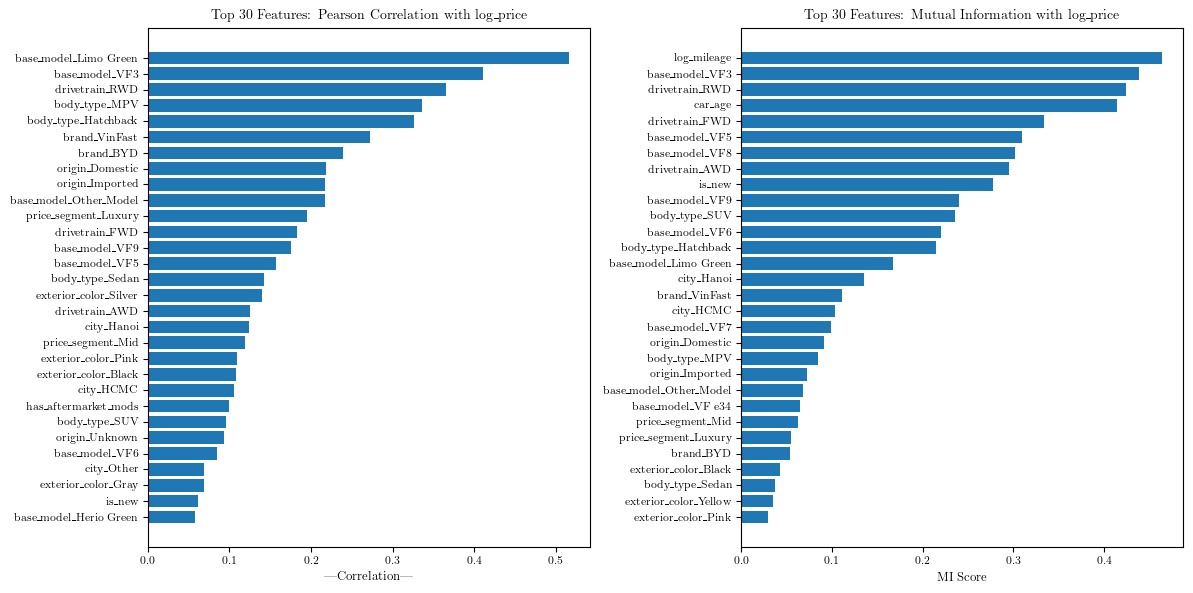

In [68]:
# Combined feature importance plot
top_n = 30
corr_df = corr_with_target.head(top_n).reset_index()
corr_df.columns = ["Feature", "Correlation"]

mi_top = mi_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].barh(corr_df["Feature"][::-1], corr_df["Correlation"][::-1])
axes[0].set_title("Top 30 Features: Pearson Correlation with log\\_price")
axes[0].set_xlabel("|Correlation|")

axes[1].barh(mi_top["Feature"][::-1].values, mi_top["MI_Score"][::-1].values)
axes[1].set_title("Top 30 Features: Mutual Information with log\\_price")
axes[1].set_xlabel("MI Score")

plt.tight_layout()
plt.savefig(REPORT_FE / "feature_importance_summary.pdf", bbox_inches="tight", format="pdf")
plt.show()

## 6. Train-Test Split \& Scaling

In [69]:
# 80/20 stratified split on brand
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=42, stratify=brand_series
)

# Log targets
y_train_log = np.log1p(y_train_raw)
y_test_log = np.log1p(y_test_raw)

# Sample weights for train set
sw_train = sample_weights.loc[X_train.index]

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nBrand distribution in train:")
print(brand_series.loc[X_train.index].value_counts().to_string())
print(f"\nBrand distribution in test:")
print(brand_series.loc[X_test.index].value_counts().to_string())

Training set: (3170, 46)
Test set:     (793, 46)

Brand distribution in train:
VinFast          2990
BYD                69
Mercedes-Benz      31
Other_Brand        30
Porsche            18
Bestune            14
Wuling             10
Geely               8

Brand distribution in test:
VinFast          748
BYD               18
Other_Brand        8
Mercedes-Benz      8
Porsche            4
Bestune            3
Geely              2
Wuling             2


**Scale numeric features** for Linear Regression and SVR. One-hot columns (0/1) are left unscaled.

In [70]:
# Identify numeric (non-dummy) columns to scale
COLS_TO_SCALE = list(set(
    [c for c in NUMERIC_FEATURES if c in X_train.columns]
    + (["car_age"] if "car_age" in X_train.columns else [])
    + (["log_mileage"] if "log_mileage" in X_train.columns else [])
))

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[COLS_TO_SCALE] = scaler.fit_transform(X_train[COLS_TO_SCALE])
X_test_scaled[COLS_TO_SCALE] = scaler.transform(X_test[COLS_TO_SCALE])

print(f"Scaled columns: {COLS_TO_SCALE}")
print(f"Scaled train sample:")
print(X_train_scaled[COLS_TO_SCALE].describe().round(2).to_string())

Scaled columns: ['log_mileage', 'is_new', 'car_age', 'has_aftermarket_mods']
Scaled train sample:
       log_mileage   is_new  car_age  has_aftermarket_mods
count      3170.00  3170.00  3170.00               3170.00
mean         -0.00     0.00    -0.00                 -0.00
std           1.00     1.00     1.00                  1.00
min          -1.10    -0.81    -1.55                 -0.35
25%          -1.10    -0.81    -0.64                 -0.35
50%           0.55    -0.81    -0.64                 -0.35
75%           0.96     1.23     0.28                 -0.35
max           1.45     1.23     8.51                  2.88


### Save All Outputs

In [71]:
# Save all processed data
# Unscaled (for Random Forest, XGBoost)
X_train.to_csv(PROCESSED / "X_train.csv", index=False)
X_test.to_csv(PROCESSED / "X_test.csv", index=False)

# Scaled (for Linear Regression, SVR)
X_train_scaled.to_csv(PROCESSED / "X_train_scaled.csv", index=False)
X_test_scaled.to_csv(PROCESSED / "X_test_scaled.csv", index=False)

# Targets
pd.Series(y_train_raw.values, name="price_vnd").to_csv(PROCESSED / "y_train.csv", index=False)
pd.Series(y_test_raw.values, name="price_vnd").to_csv(PROCESSED / "y_test.csv", index=False)
pd.Series(y_train_log.values, name="log_price").to_csv(PROCESSED / "y_train_log.csv", index=False)
pd.Series(y_test_log.values, name="log_price").to_csv(PROCESSED / "y_test_log.csv", index=False)

# Sample weights
pd.Series(sw_train.values, name="weight").to_csv(PROCESSED / "sample_weights_train.csv", index=False)

# Feature names
pd.Series(X_train.columns, name="feature").to_csv(PROCESSED / "feature_names.csv", index=False)

# Scaler
joblib.dump(scaler, PROCESSED / "scaler.joblib")

print("All files saved to:", PROCESSED)
for f in sorted(PROCESSED.iterdir()):
    size = f.stat().st_size
    print(f"  {f.name}: {size:,} bytes")

All files saved to: C:\Users\dduya\Work\project\ev_car\data\processed
  feature_names.csv: 815 bytes
  sample_weights_train.csv: 66,141 bytes
  scaler.joblib: 983 bytes
  X_test.csv: 83,870 bytes
  X_test_scaled.csv: 130,436 bytes
  X_train.csv: 334,093 bytes
  X_train_scaled.csv: 519,076 bytes
  y_test.csv: 10,535 bytes
  y_test_log.csv: 15,582 bytes
  y_train.csv: 42,108 bytes
  y_train_log.csv: 62,242 bytes


### Final Summary

In [72]:
print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)
print(f"\nTraining set:  {X_train.shape[0]:,} samples x {X_train.shape[1]} features")
print(f"Test set:      {X_test.shape[0]:,} samples x {X_test.shape[1]} features")
print(f"\nTarget (raw):  min={y_train_raw.min():,.0f}, median={y_train_raw.median():,.0f}, max={y_train_raw.max():,.0f}")
print(f"Target (log):  min={y_train_log.min():.2f}, median={y_train_log.median():.2f}, max={y_train_log.max():.2f}")
print(f"Target (log) skewness: {y_train_log.skew():.4f}")
print(f"\nFeatures saved: {len(X_train.columns)}")
print(f"Low-variance dropped: {len(low_var)}")
print(f"VIF dropped: {len(dropped_vif)}")

FEATURE ENGINEERING COMPLETE

Training set:  3,170 samples x 46 features
Test set:      793 samples x 46 features

Target (raw):  min=50,000,000, median=689,000,000, max=15,690,000,000
Target (log):  min=17.73, median=20.35, max=23.48
Target (log) skewness: 0.9570

Features saved: 46
Low-variance dropped: 23
VIF dropped: 3


**Model Readiness Table**

| Model | Features file | Target file | Notes |
|---|---|---|---|
| Linear Regression | `X\_train\_scaled.csv` | `y\_train\_log.csv` | Log target, scaled features |
| SVR | `X\_train\_scaled.csv` | `y\_train\_log.csv` | Log target, scaled features |
| Random Forest | `X\_train.csv` | `y\_train.csv` | Raw target, unscaled features |
| XGBoost | `X\_train.csv` | `y\_train.csv` | Raw target, unscaled features |

`sample\_weights\_train.csv` contains inverse-frequency brand weights for optional use during training.